ENVIRONMENT PREPARATION

Import Library

In [ ]:
#import library yang diperlukan
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob

sns.set(style="whitegrid")

Import Dataset

In [ ]:
#import dataset

# Tentukan lokasi folder yang berisi semua file CSV
folder_path = '/content/drive/MyDrive/Data Analyst/Studi-Kasus-1/divvy-tripdata_original/'

# Ambil semua file yang berakhiran .csv di folder tersebut
csv_files = glob.glob(folder_path + '*.csv')

# Gabungkan semua file menjadi satu DataFrame
df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list, ignore_index=True)

# Tampilkan beberapa baris awal
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,2658E319B13141F9,electric_bike,2024-07-11 08:15:14.784,2024-07-11 08:17:56.335,NaN,NaN,NaN,NaN,41.80,-87.59,41.79,-87.59,casual
1,B2176315168A47CE,electric_bike,2024-07-11 15:45:07.851,2024-07-11 16:06:04.243,NaN,NaN,NaN,NaN,41.79,-87.60,41.80,-87.59,casual
2,C2A9D33DF7EBB422,electric_bike,2024-07-11 08:24:48.192,2024-07-11 08:28:05.237,NaN,NaN,NaN,NaN,41.79,-87.59,41.79,-87.60,casual
3,8BFEA406DF01D8AD,electric_bike,2024-07-11 08:46:06.864,2024-07-11 09:14:11.664,NaN,NaN,NaN,NaN,41.88,-87.64,41.90,-87.67,casual
4,ECD3EF02E5EB73B6,electric_bike,2024-07-11 18:18:16.588,2024-07-11 18:30:20.288,NaN,NaN,NaN,NaN,41.95,-87.64,41.91,-87.62,casual


DATA CLEANING

Drop Columns

In [ ]:
# Hapus kolom yang tidak relevan/diperlukan

columns_to_drop = [
    'ride_id', 'start_station_name', 'start_station_id',
    'end_station_name', 'end_station_id',
    'start_lat', 'start_lng', 'end_lat', 'end_lng'
]

df_cleaned = df.drop(columns=columns_to_drop)

df_cleaned.head()

,rideable_type,started_at,ended_at,member_casual
0,electric_bike,2024-07-11 08:15:14.784,2024-07-11 08:17:56.335,casual
1,electric_bike,2024-07-11 15:45:07.851,2024-07-11 16:06:04.243,casual
2,electric_bike,2024-07-11 08:24:48.192,2024-07-11 08:28:05.237,casual
3,electric_bike,2024-07-11 08:46:06.864,2024-07-11 09:14:11.664,casual
4,electric_bike,2024-07-11 18:18:16.588,2024-07-11 18:30:20.288,casual


Konversi Tipe Data Datetime dari String ke Python

In [ ]:
# Konversi format String menjadi datetime python agar bisa dilakukan penghitungan waktu
df_cleaned['started_at'] = pd.to_datetime(df_cleaned['started_at'])
df_cleaned['ended_at'] = pd.to_datetime(df_cleaned['ended_at'])

MENGOLAH DATA

Poin-A Hour

In [ ]:
# Mencari data waktu (Hour) pengguna memulai bersepeda dari kolom started_at, ditampilkan dalam format 24 jam
df_cleaned['hour'] = df_cleaned['started_at'].dt.hour
df_cleaned.head()

,rideable_type,started_at,ended_at,member_casual,hour
0,electric_bike,2024-07-11 08:15:14.784,2024-07-11 08:17:56.335,casual,8
1,electric_bike,2024-07-11 15:45:07.851,2024-07-11 16:06:04.243,casual,15
2,electric_bike,2024-07-11 08:24:48.192,2024-07-11 08:28:05.237,casual,8
3,electric_bike,2024-07-11 08:46:06.864,2024-07-11 09:14:11.664,casual,8
4,electric_bike,2024-07-11 18:18:16.588,2024-07-11 18:30:20.288,casual,18


Poin-B Name of The Day

In [ ]:
# Mencari data waktu (name_of_the_day) pengguna memulai bersepeda dari kolom started_at
df_cleaned['day_of_week'] = df_cleaned['started_at'].dt.day_name()
df_cleaned.head()

,rideable_type,started_at,ended_at,member_casual,hour,day_of_week
0,electric_bike,2024-07-11 08:15:14.784,2024-07-11 08:17:56.335,casual,8,Thursday
1,electric_bike,2024-07-11 15:45:07.851,2024-07-11 16:06:04.243,casual,15,Thursday
2,electric_bike,2024-07-11 08:24:48.192,2024-07-11 08:28:05.237,casual,8,Thursday
3,electric_bike,2024-07-11 08:46:06.864,2024-07-11 09:14:11.664,casual,8,Thursday
4,electric_bike,2024-07-11 18:18:16.588,2024-07-11 18:30:20.288,casual,18,Thursday


Poin-C Month

In [ ]:
# Mencari data waktu (Month) pengguna memulai bersepeda dari kolom started_at, ditampilkan dalam format 24 jam
df_cleaned['month'] = df_cleaned['started_at'].dt.month
df_cleaned.head()

,rideable_type,started_at,ended_at,member_casual,hour,day_of_week,month
0,electric_bike,2024-07-11 08:15:14.784,2024-07-11 08:17:56.335,casual,8,Thursday,7
1,electric_bike,2024-07-11 15:45:07.851,2024-07-11 16:06:04.243,casual,15,Thursday,7
2,electric_bike,2024-07-11 08:24:48.192,2024-07-11 08:28:05.237,casual,8,Thursday,7
3,electric_bike,2024-07-11 08:46:06.864,2024-07-11 09:14:11.664,casual,8,Thursday,7
4,electric_bike,2024-07-11 18:18:16.588,2024-07-11 18:30:20.288,casual,18,Thursday,7


Poin-D ride_length

In [ ]:
# Mencari durasi pengguna bersepeda
df_cleaned['ride_length'] = (df_cleaned['ended_at'] - df_cleaned['started_at']).dt.total_seconds() / 60
df_cleaned.head()

,rideable_type,started_at,ended_at,member_casual,hour,day_of_week,month,ride_length
0,electric_bike,2024-07-11 08:15:14.784,2024-07-11 08:17:56.335,casual,8,Thursday,7,2.692517
1,electric_bike,2024-07-11 15:45:07.851,2024-07-11 16:06:04.243,casual,15,Thursday,7,20.939867
2,electric_bike,2024-07-11 08:24:48.192,2024-07-11 08:28:05.237,casual,8,Thursday,7,3.284083
3,electric_bike,2024-07-11 08:46:06.864,2024-07-11 09:14:11.664,casual,8,Thursday,7,28.080000
4,electric_bike,2024-07-11 18:18:16.588,2024-07-11 18:30:20.288,casual,18,Thursday,7,12.061667


Poin-E category_ride_length

In [ ]:
# Kategori dari lama durasi
def kategori_durasi(ride_length):
    if ride_length <= 10:
        return '<=10'
    elif ride_length <= 20:
        return '>10 and <=20'
    elif ride_length <= 30:
        return '>20 and <=30'
    else:
        return 'Over 30'

df_cleaned['ride_length_category'] = df_cleaned['ride_length'].apply(kategori_durasi)
df_cleaned.head()

,rideable_type,started_at,ended_at,member_casual,hour,day_of_week,month,ride_length,ride_length_category
0,electric_bike,2024-07-11 08:15:14.784,2024-07-11 08:17:56.335,casual,8,Thursday,7,2.692517,<=10
1,electric_bike,2024-07-11 15:45:07.851,2024-07-11 16:06:04.243,casual,15,Thursday,7,20.939867,>20 and <=30
2,electric_bike,2024-07-11 08:24:48.192,2024-07-11 08:28:05.237,casual,8,Thursday,7,3.284083,<=10
3,electric_bike,2024-07-11 08:46:06.864,2024-07-11 09:14:11.664,casual,8,Thursday,7,28.080000,>20 and <=30
4,electric_bike,2024-07-11 18:18:16.588,2024-07-11 18:30:20.288,casual,18,Thursday,7,12.061667,>10 and <=20


PENGECEKAN DATASET ULANG

In [ ]:
# Pengecekan Ulang Kebersihan Data

# Tujuan kebersihan data:
# 1. Tidak ada missing value di kolom penting
# 2. Tidak ada duplikat
# 3. Semua kolom bertipe data yang benar
# 4. Durasi perjalanan (ride_length) sudah positif dan logis
# 5. Tidak ada outlier ekstrem yang merusak analisis


# Mengecek tipe data tiap kolom
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5597030 entries, 0 to 5597029
Data columns (total 9 columns):
 #   Column                Dtype         
---  ------                -----         
 0   rideable_type         object        
 1   started_at            datetime64[ns]
 2   ended_at              datetime64[ns]
 3   member_casual         object        
 4   hour                  int32         
 5   day_of_week           object        
 6   month                 int32         
 7   ride_length           float64       
 8   ride_length_category  object        
dtypes: datetime64[ns](2), float64(1), int32(2), object(4)
memory usage: 341.6+ MB


In [ ]:
# Mengecek apakah ada data yang null
df_cleaned.isnull().sum()

,0
rideable_type,0
started_at,0
ended_at,0
member_casual,0
hour,0
day_of_week,0
month,0
ride_length,0
ride_length_category,0


In [ ]:
# cek duplikat
df_cleaned.duplicated().sum()

np.int64(0)

In [ ]:
# cek durasi apabila penggunaan > 1 Hari (1440 menit)
df_cleaned[df_cleaned['ride_length'] > 1440]

,rideable_type,started_at,ended_at,member_casual,hour,day_of_week,month,ride_length,ride_length_category
6336,classic_bike,2024-07-05 01:12:00.820,2024-07-06 02:11:52.858,casual,1,Friday,7,1499.867300,Over 30
9228,classic_bike,2024-07-27 19:05:21.358,2024-07-28 20:05:15.506,casual,19,Saturday,7,1499.902467,Over 30
14437,classic_bike,2024-07-13 19:31:54.394,2024-07-14 20:31:49.901,member,19,Saturday,7,1499.925117,Over 30
14527,classic_bike,2024-07-26 15:50:59.026,2024-07-27 16:50:39.502,casual,15,Friday,7,1499.674600,Over 30
14585,classic_bike,2024-07-21 06:51:48.711,2024-07-22 07:51:43.107,casual,6,Sunday,7,1499.906600,Over 30
...,...,...,...,...,...,...,...,...,...
5580611,classic_bike,2025-06-06 17:35:17.638,2025-06-07 18:35:09.682,casual,17,Friday,6,1499.867400,Over 30
5585382,classic_bike,2025-06-10 22:12:58.840,2025-06-11 23:12:55.346,casual,22,Tuesday,6,1499.941767,Over 30
5585507,classic_bike,2025-06-28 09:21:30.056,2025-06-29 10:21:13.815,casual,9,Saturday,6,1499.729317,Over 30
5585607,classic_bike,2025-06-03 18:44:06.460,2025-06-04 19:43:56.417,member,18,Tuesday,6,1499.832617,Over 30


In [ ]:
# Karena ada durasi apabila penggunaan > 1 Hari (1440 menit), dinilai merusak penghitungan average maka dihapus saja
df_cleaned = df_cleaned[df_cleaned['ride_length'] <= 1440]

In [ ]:
#data setelah dilakukan penghapusan
df_cleaned['ride_length'].describe()

,ride_length
count,5.590841e+06
mean,1.480897e+01
std,2.895819e+01
min,-5.602170e+01
25%,5.414450e+00
50%,9.458883e+00
75%,1.667113e+01
max,1.439935e+03


HASIL

Poin-A Total Perjalan Pengguna

,user_type,count
0,member,3540919
1,casual,2049922


/tmp/ipython-input-40-1556472659.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=user_counts, x='user_type', y='count', palette='pastel')


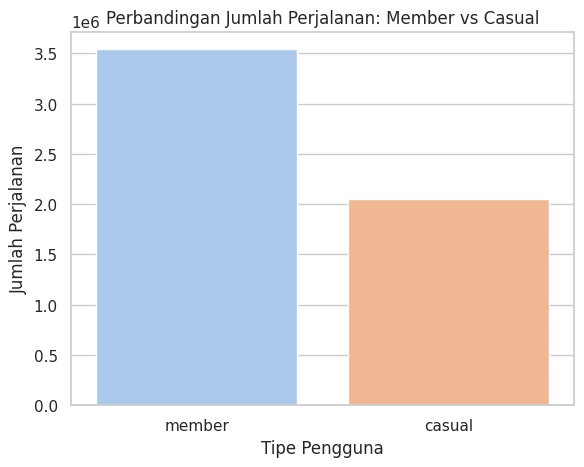

In [ ]:
# Mencari data perbandingan antara pengguna casual dan member

user_counts = df_cleaned['member_casual'].value_counts().reset_index()
user_counts.columns = ['user_type', 'count']
display(user_counts)

# Chart dengan Seaborn

# Plot
plt.figure(figsize=(6, 5))
sns.barplot(data=user_counts, x='user_type', y='count', palette='pastel')

plt.title('Perbandingan Jumlah Perjalanan: Member vs Casual')
plt.xlabel('Tipe Pengguna')
plt.ylabel('Jumlah Perjalanan')
plt.tight_layout()
plt.show()

Poin-B Average Durasi Perjalanan

In [ ]:
# Mengelompokkan data berdasarkan jenis pengguna (casual atau member),
# lalu menghitung rata-rata durasi perjalanan
avg_ride_length = df_cleaned.groupby('member_casual')['ride_length'].mean().reset_index()
avg_ride_length.columns = ['user_type', 'average_ride_length']

# Menampilkan tabel hasil
display(avg_ride_length)

,user_type,average_ride_length
0,casual,19.961422
1,member,11.826100


/tmp/ipython-input-43-1549044123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


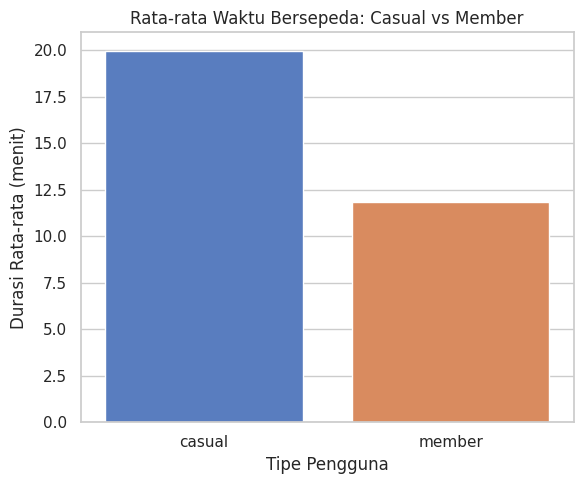

In [ ]:
# Visualisasi
plt.figure(figsize=(6, 5))  # Ukuran gambar
sns.barplot(
    data=avg_ride_length,  # Dataset yang digunakan
    x='user_type',         # Kolom untuk sumbu X
    y='average_ride_length',  # Kolom untuk sumbu Y
    palette='muted'        # Warna grafik
)

plt.title('Rata-rata Waktu Bersepeda: Casual vs Member')  # Judul grafik
plt.xlabel('Tipe Pengguna')       # Label X
plt.ylabel('Durasi Rata-rata (menit)')  # Label Y
plt.tight_layout()
plt.show()


Poin-C Jumlah Perjalanan Pengguna Dalam Hari

In [ ]:
# Kelompokkan data berdasarkan jenis pengguna dan total perjalanan per hari
trip_counts_per_day = df_cleaned.groupby(['member_casual', 'day_of_week']).size().reset_index(name='trip_count')
trip_counts_per_day.rename(columns={'member_casual': 'user_type'}, inplace=True)

# Atur urutan hari agar tidak acak
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
trip_counts_per_day['day_of_week'] = pd.Categorical(trip_counts_per_day['day_of_week'], categories=day_order, ordered=True)

# Urutkan
trip_counts_per_day = trip_counts_per_day.sort_values(['user_type', 'day_of_week'])

display(trip_counts_per_day)


,user_type,day_of_week,trip_count
3,casual,Sunday,334704
1,casual,Monday,246267
5,casual,Tuesday,224033
6,casual,Wednesday,236486
4,casual,Thursday,262157
0,casual,Friday,320055
2,casual,Saturday,426220
10,member,Sunday,384660
8,member,Monday,522537
12,member,Tuesday,549996


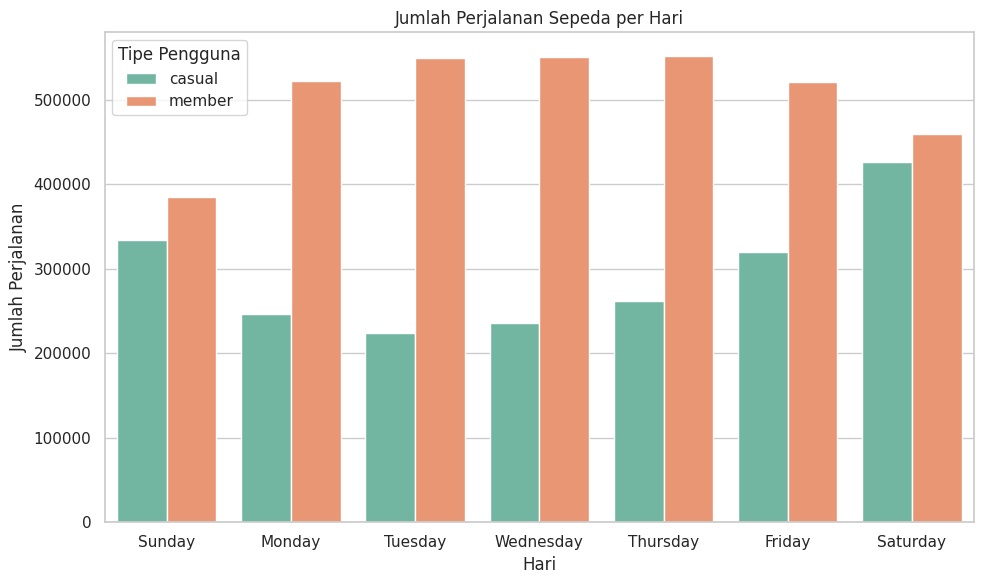

In [ ]:
# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(
    data=trip_counts_per_day,
    x='day_of_week',
    y='trip_count',
    hue='user_type',
    palette='Set2'
)

plt.title('Jumlah Perjalanan Sepeda per Hari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Perjalanan')
plt.legend(title='Tipe Pengguna')
plt.tight_layout()
plt.show()

Poin-D Average ride_length

In [ ]:
# Hitung rata-rata durasi perjalanan berdasarkan tipe pengguna dan hari
avg_ride_per_day = df_cleaned.groupby(['member_casual', 'day_of_week'])['ride_length'].mean().reset_index()

day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
avg_ride_per_day['day_of_week'] = pd.Categorical(avg_ride_per_day['day_of_week'], categories=day_order, ordered=True)
avg_ride_per_day = avg_ride_per_day.sort_values(['member_casual', 'day_of_week'])

# Tampilkan data (opsional)
display(avg_ride_per_day)

,member_casual,day_of_week,ride_length
3,casual,Sunday,22.815641
1,casual,Monday,19.368944
5,casual,Tuesday,17.476316
6,casual,Wednesday,17.169685
4,casual,Thursday,17.725920
0,casual,Friday,19.529074
2,casual,Saturday,22.617257
10,member,Sunday,12.974807
8,member,Monday,11.345779
12,member,Tuesday,11.371340


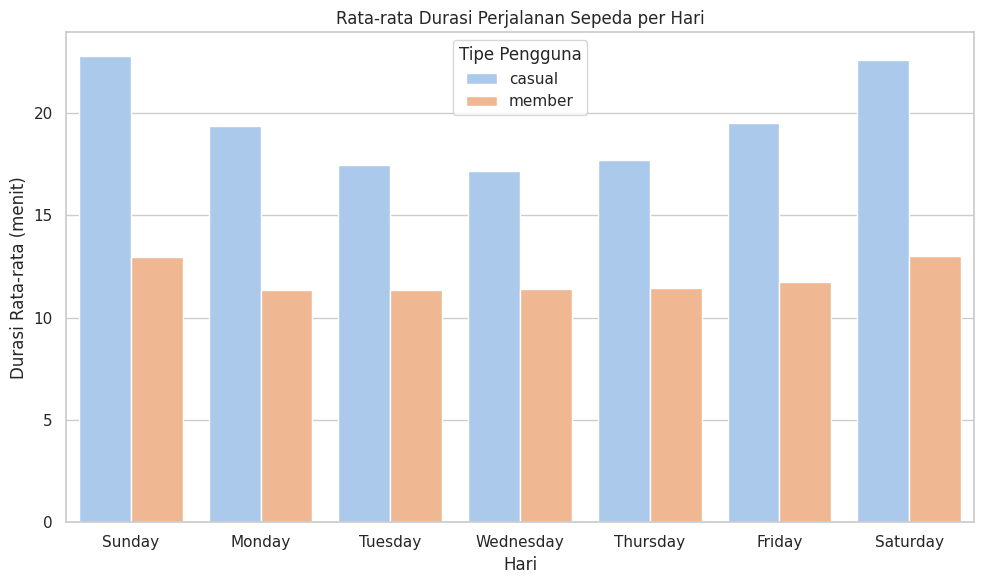

In [ ]:
# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(
    data=avg_ride_per_day,
    x='day_of_week',
    y='ride_length',
    hue='member_casual',
    palette='pastel'
)

plt.title('Rata-rata Durasi Perjalanan Sepeda per Hari')
plt.xlabel('Hari')
plt.ylabel('Durasi Rata-rata (menit)')
plt.legend(title='Tipe Pengguna')
plt.tight_layout()
plt.show()

Poin-E Jumlah Penggunaan Pesepeda

In [ ]:
# Analisis jam favorit (rata-rata waktu sepeda digunakan) antara casual dan member berdasarkan hari seminggu

# Atur urutan hari agar grafik tidak acak
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

usage_by_hour_day = df_cleaned.groupby(['member_casual', 'day_of_week', 'hour'])['ride_length'].count().reset_index()
usage_by_hour_day.columns = ['user_type', 'day_of_week', 'hour', 'trip_count']

usage_by_hour_day['day_of_week'] = pd.Categorical(usage_by_hour_day['day_of_week'], categories=day_order, ordered=True)
usage_by_hour_day = usage_by_hour_day.sort_values(['user_type', 'day_of_week', 'hour'])

display(usage_by_hour_day)

,user_type,day_of_week,hour,trip_count
72,casual,Sunday,0,10156
73,casual,Sunday,1,7141
74,casual,Sunday,2,4516
75,casual,Sunday,3,2537
76,casual,Sunday,4,1757
...,...,...,...,...
235,member,Saturday,19,23688
236,member,Saturday,20,17544
237,member,Saturday,21,14576
238,member,Saturday,22,13640


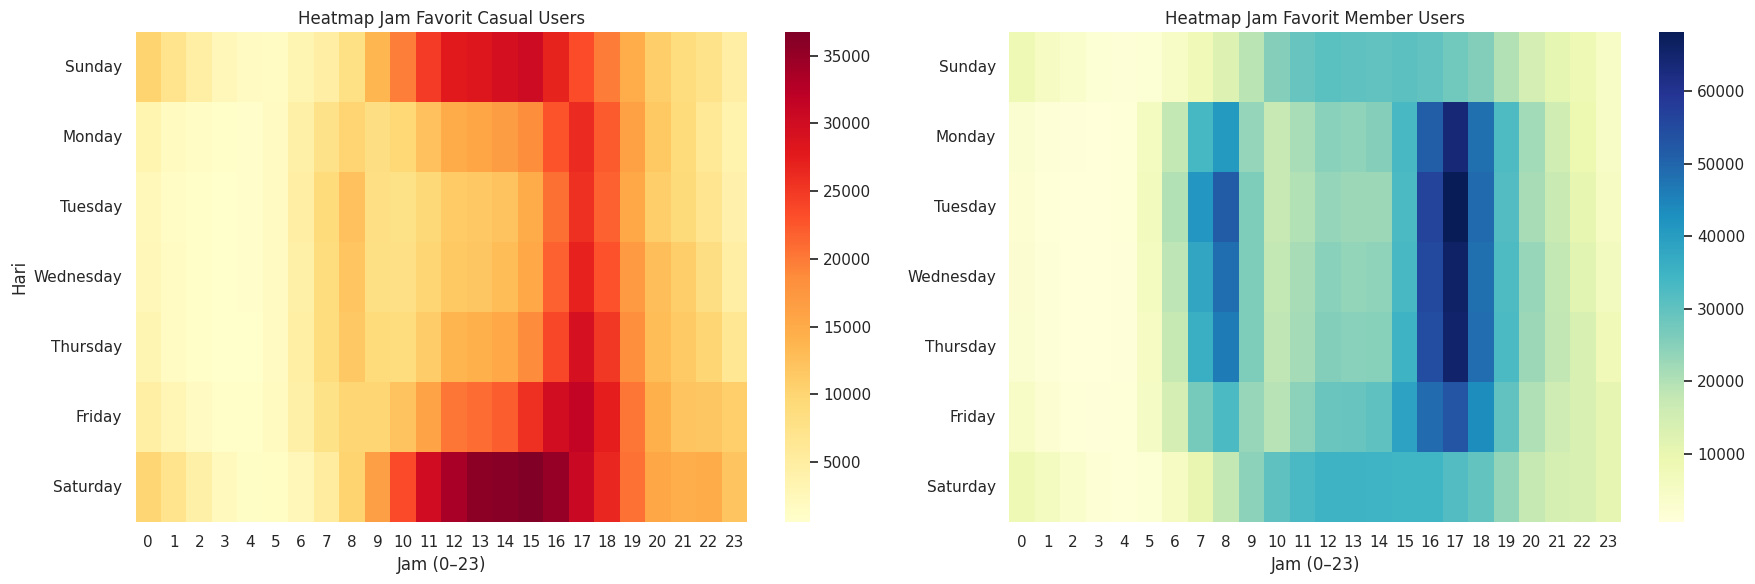

In [ ]:
# Visualisasi 1

# Import pivot_table untuk membuat matriks hari vs jam
pivot_casual = usage_by_hour_day[usage_by_hour_day['user_type'] == 'casual'].pivot(index='day_of_week', columns='hour', values='trip_count')
pivot_member = usage_by_hour_day[usage_by_hour_day['user_type'] == 'member'].pivot(index='day_of_week', columns='hour', values='trip_count')

plt.figure(figsize=(18, 6))

# Heatmap untuk Casual
plt.subplot(1, 2, 1)
sns.heatmap(pivot_casual, cmap='YlOrRd')
plt.title('Heatmap Jam Favorit Casual Users')
plt.xlabel('Jam (0–23)')
plt.ylabel('Hari')

# Heatmap untuk Member
plt.subplot(1, 2, 2)
sns.heatmap(pivot_member, cmap='YlGnBu')
plt.title('Heatmap Jam Favorit Member Users')
plt.xlabel('Jam (0–23)')
plt.ylabel('')

plt.tight_layout()
plt.show()

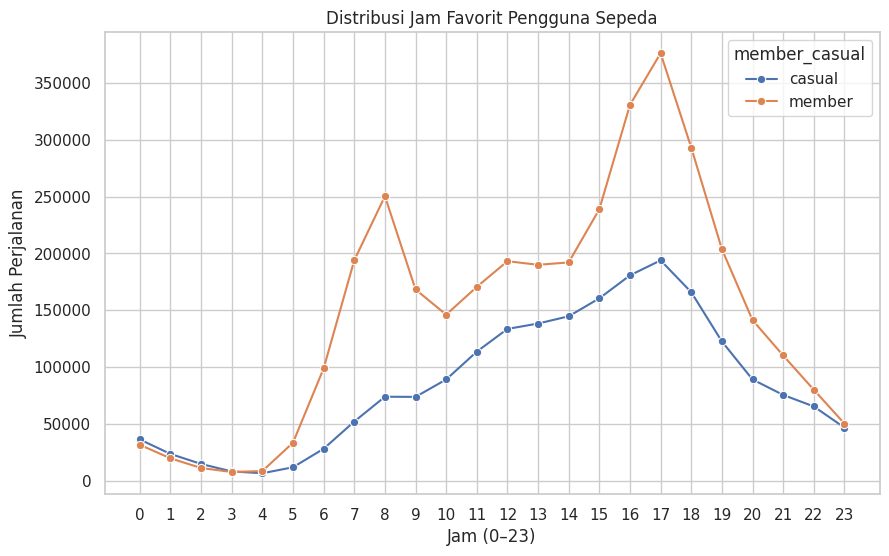

In [ ]:
# Visualisasi 2
usage_by_hour = df_cleaned.groupby(['member_casual', 'hour'])['ride_length'].count().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=usage_by_hour, x='hour', y='ride_length', hue='member_casual', marker='o')
plt.title('Distribusi Jam Favorit Pengguna Sepeda')
plt.xlabel('Jam (0–23)')
plt.ylabel('Jumlah Perjalanan')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

Poin-F Kategori Lama Waktu Pengguna Bersepeda

In [ ]:
# Kategori Durasi

def kategori_durasi(ride_length):
    if ride_length <= 10:
        return '<=10'
    elif ride_length <= 20:
        return '>10 and <=20'
    elif ride_length <= 30:
        return '>20 and <=30'
    else:
        return 'Over 30'

df_cleaned['ride_length_category'] = df_cleaned['ride_length'].apply(kategori_durasi)

#Table Perbandingan
duration_dist = df_cleaned.groupby(['member_casual', 'ride_length_category'])['ride_length'].count().reset_index()
duration_dist.columns = ['user_type', 'duration_category', 'trip_count']
display(duration_dist)

,user_type,duration_category,trip_count
0,casual,<=10,887173
1,casual,>10 and <=20,593724
2,casual,>20 and <=30,244300
3,casual,Over 30,324725
4,member,<=10,2057844
5,member,>10 and <=20,997043
6,member,>20 and <=30,298530
7,member,Over 30,187502


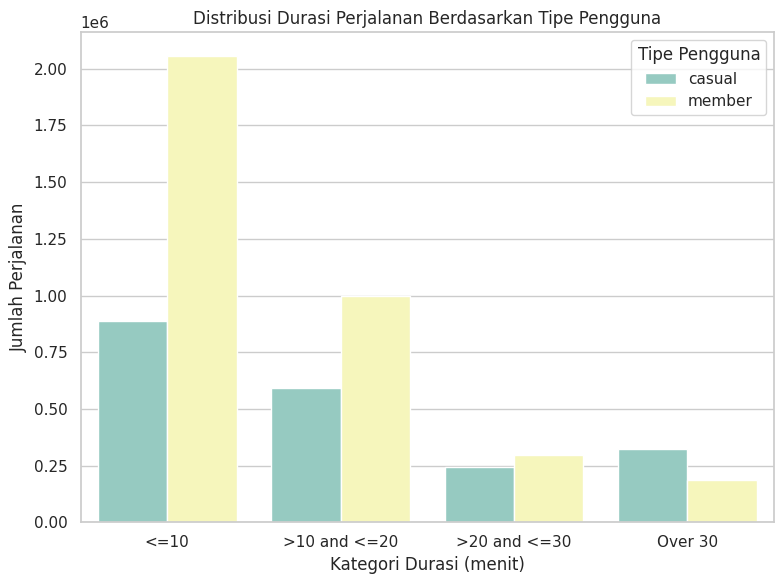

In [ ]:
#Visualisasi
plt.figure(figsize=(8, 6))
sns.barplot(
    data=duration_dist,
    x='duration_category',
    y='trip_count',
    hue='user_type',
    palette='Set3'
)

plt.title('Distribusi Durasi Perjalanan Berdasarkan Tipe Pengguna')
plt.xlabel('Kategori Durasi (menit)')
plt.ylabel('Jumlah Perjalanan')
plt.legend(title='Tipe Pengguna')
plt.tight_layout()
plt.show()

Poin-G Jumlah Perjalanan per Bulan

In [ ]:
#  Jumlah Perjalanan per Bulan
trip_per_month = df_cleaned.groupby(['member_casual', 'month'])['ride_length'].count().reset_index()
trip_per_month.columns = ['user_type', 'month', 'trip_count']

display(trip_per_month)

,user_type,month,trip_count
0,casual,1,24076
1,casual,2,27709
2,casual,3,85662
3,casual,4,108971
4,casual,5,182263
5,casual,6,291205
6,casual,7,319560
7,casual,8,317542
8,casual,9,345854
9,casual,10,215933


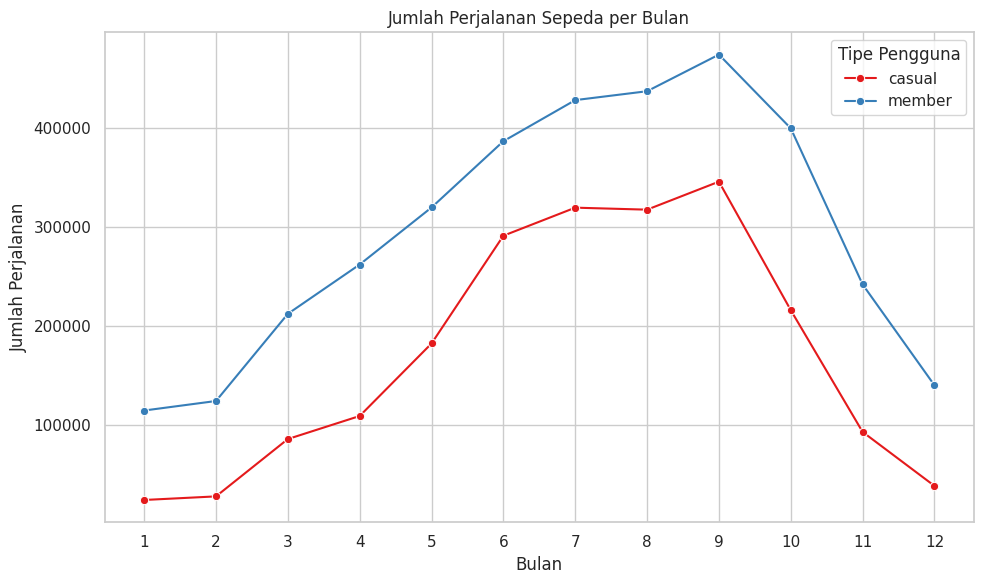

In [ ]:
#Visualisasi
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=trip_per_month,
    x='month',
    y='trip_count',
    hue='user_type',
    marker='o',
    palette='Set1'
)

plt.title('Jumlah Perjalanan Sepeda per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Perjalanan')
plt.xticks(range(1, 13))  # agar hanya menampilkan angka 1–12
plt.grid(True)
plt.legend(title='Tipe Pengguna')
plt.tight_layout()
plt.show()